In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import ggplot, aes, geom_point, labs, theme, element_text
from plotnine.themes import theme_matplotlib
ames = pd.read_csv('ames.csv')

# Relacion entre dos variables 

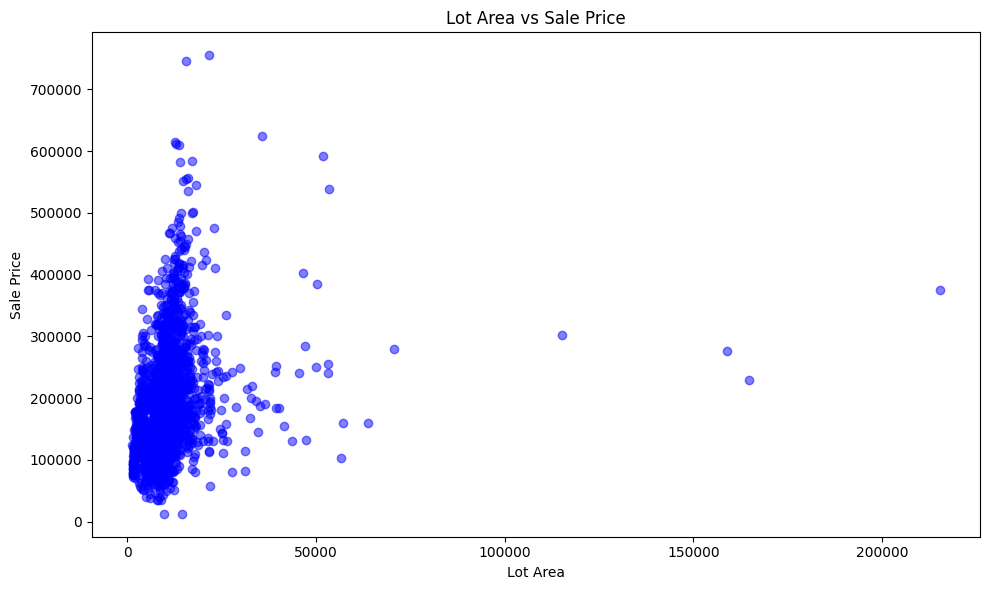

In [ ]:
p = (
    ggplot(ames, aes(x='Lot_Area', y='Sale_Price'))
    + geom_point(color='blue', alpha=0.5)
    + labs(
        x='Lot Area',
        y='Sale Price',
        title='Lot Area vs Sale Price'
    )
    # Opcional: usar un tema que se vea similar a matplotlib
    + theme_matplotlib()
    + theme(
        figure_size=(10, 6),            # Tamaño en pulgadas (similar a plt.figure(figsize=(10,6)))
        plot_title=element_text(ha='center')  # Título centrado (opcional)
    )
)

p

In [4]:
import numpy as np
ames['log_Lot_Area'] = np.log(ames['Lot_Area'])
ames['log_Sale_Price'] = np.log(ames['Sale_Price'])

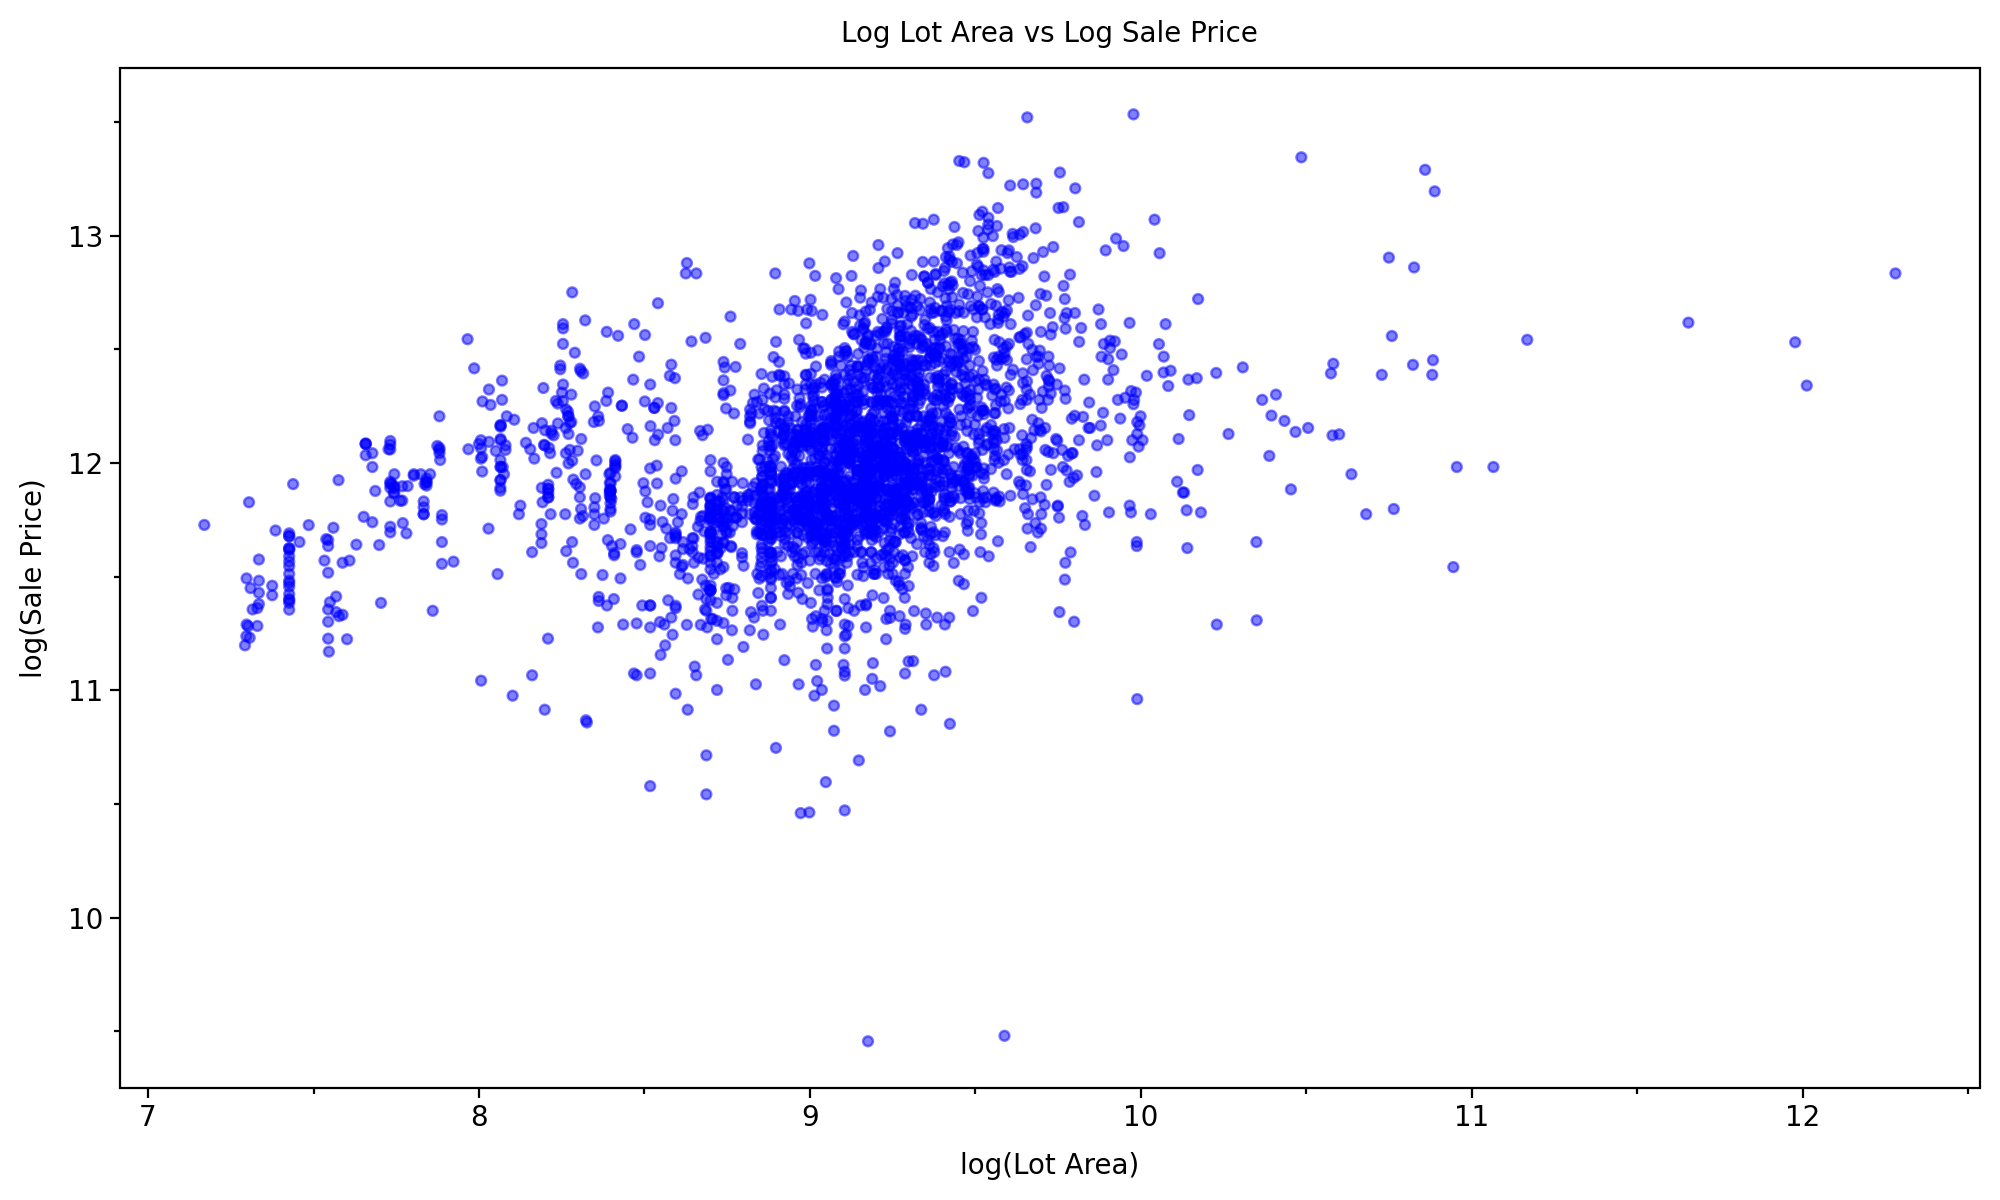

In [5]:
p = (
    ggplot(ames, aes(x='log_Lot_Area', y='log_Sale_Price'))
    + geom_point(color='blue', alpha=0.5)
    + labs(
        x='log(Lot Area)',
        y='log(Sale Price)',
        title='Log Lot Area vs Log Sale Price'
    )
    + theme_matplotlib()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(ha='center')
    )
)

p

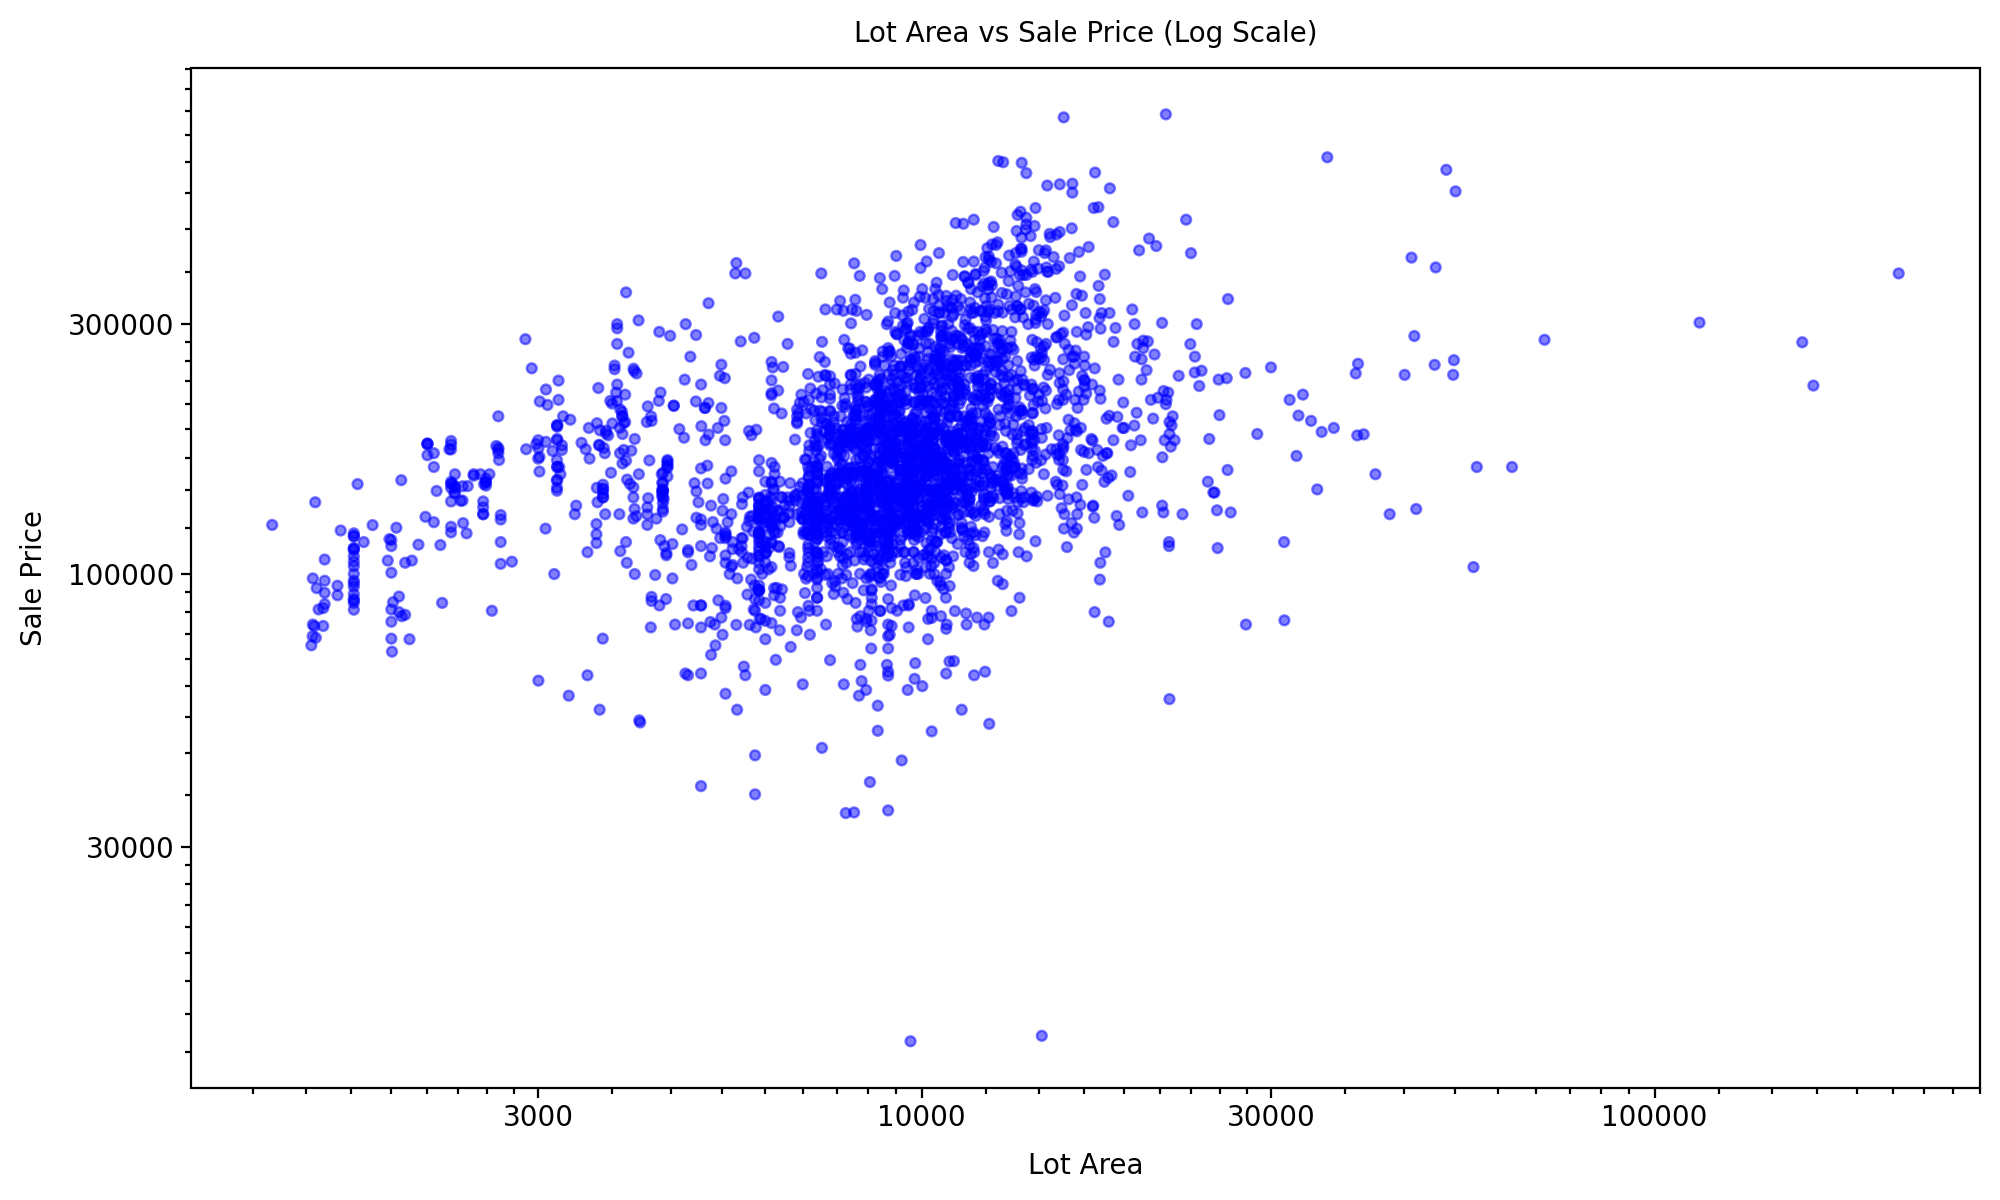

In [6]:
from plotnine import (
    ggplot, aes, geom_point, labs, theme, element_text,
    scale_x_log10, scale_y_log10
)
from plotnine.themes import theme_matplotlib

p = (
    ggplot(ames, aes(x='Lot_Area', y='Sale_Price'))
    + geom_point(color='blue', alpha=0.5)
    + scale_x_log10()
    + scale_y_log10()
    + labs(
        x='Lot Area',
        y='Sale Price',
        title='Lot Area vs Sale Price (Log Scale)'
    )
    + theme_matplotlib()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(ha='center')
    )
)

p

## Caption

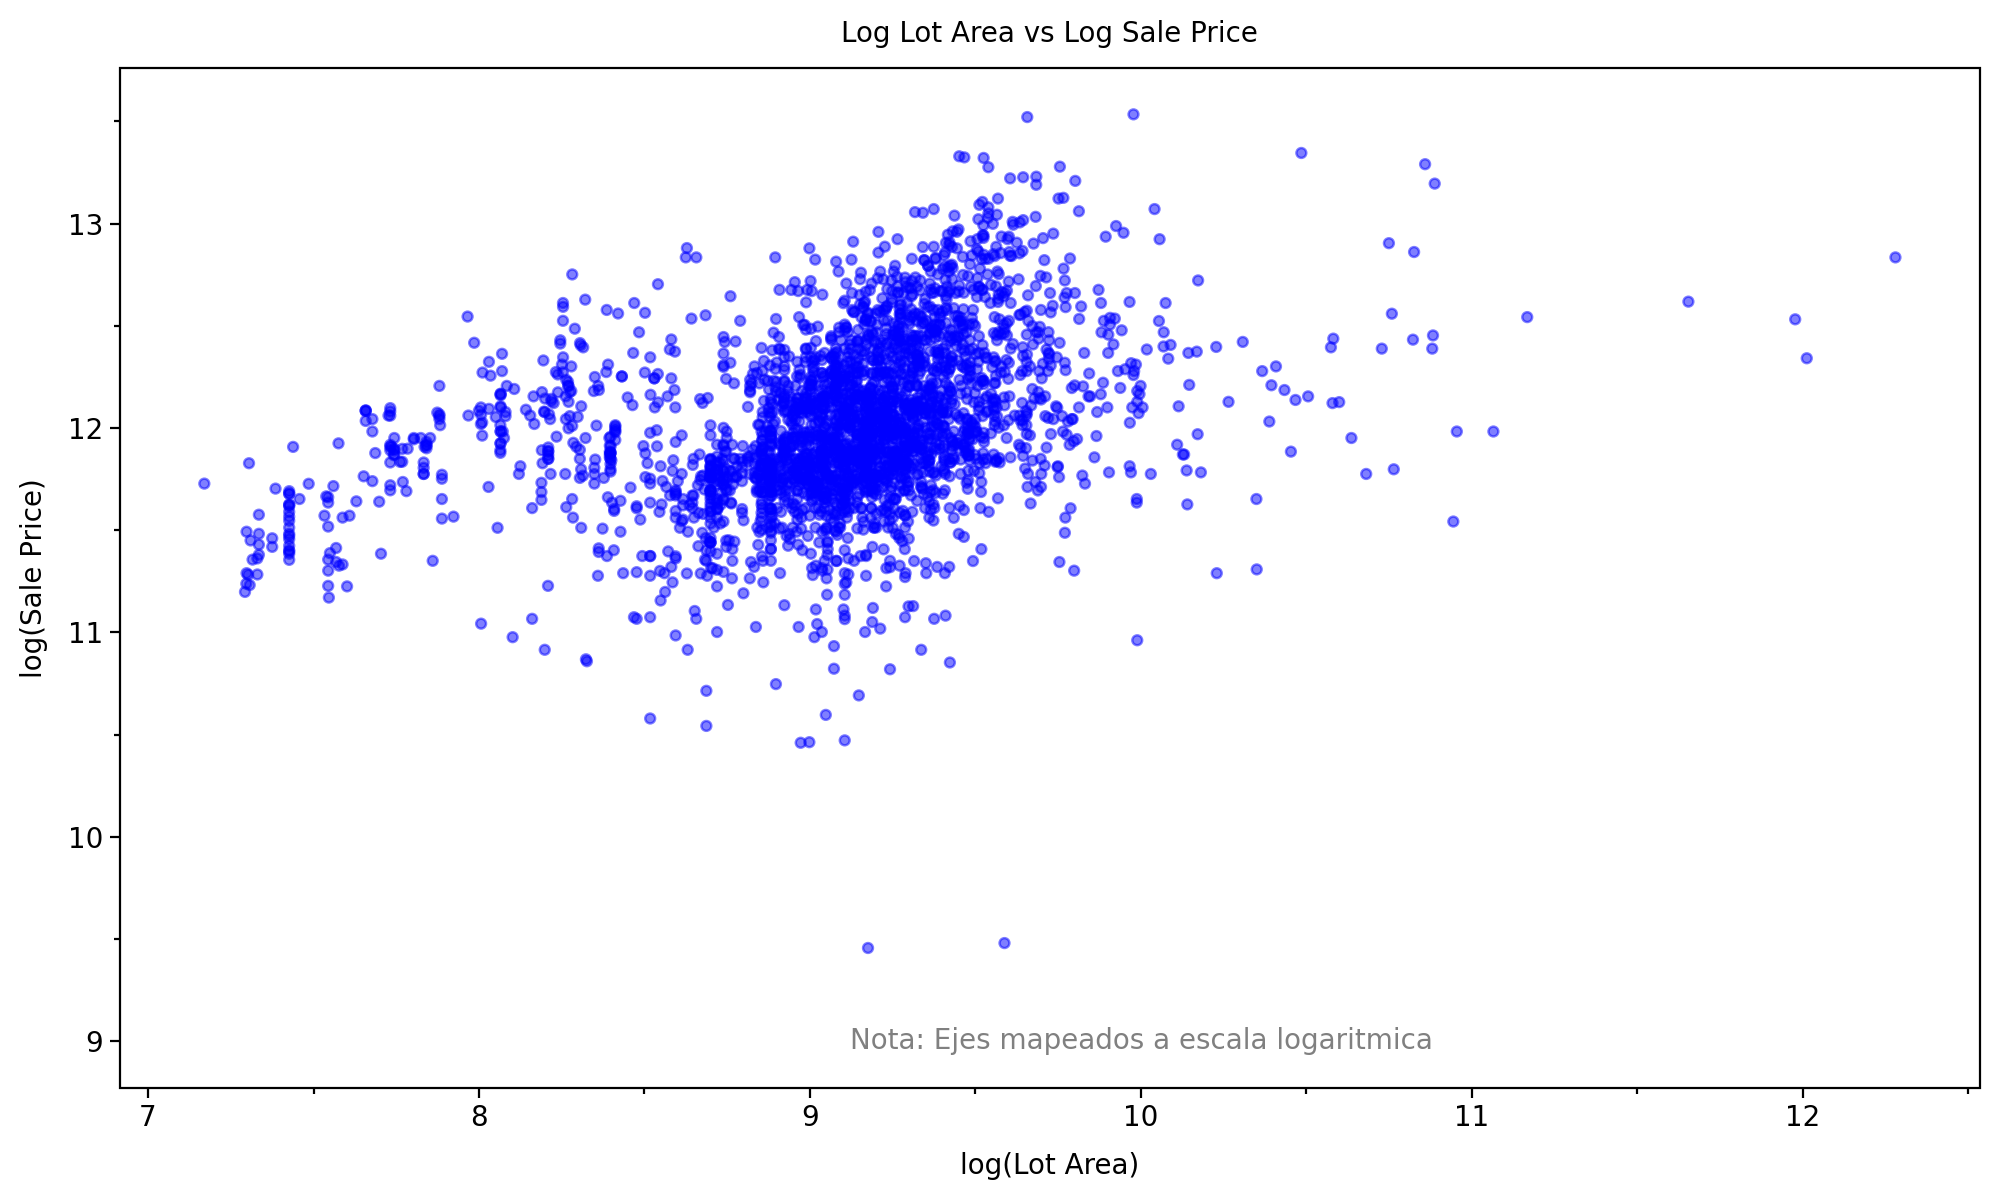

In [23]:
from plotnine import (
    ggplot, aes, geom_point, labs, theme, element_text, annotate
)
from plotnine.themes import theme_matplotlib

p = (
    ggplot(ames, aes(x='log_Lot_Area', y='log_Sale_Price'))
    + geom_point(color='blue', alpha=0.5)
    + labs(
        x='log(Lot Area)',
        y='log(Sale Price)',
        title='Log Lot Area vs Log Sale Price'
    )
    
    + annotate(
        "text",
        x=10, y=9, 
        label='Nota: Ejes mapeados a escala logaritmica',
        ha='center', va='center',
        size=10, color='gray'
    )
    + theme_matplotlib()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(ha='center')
    )
)

p

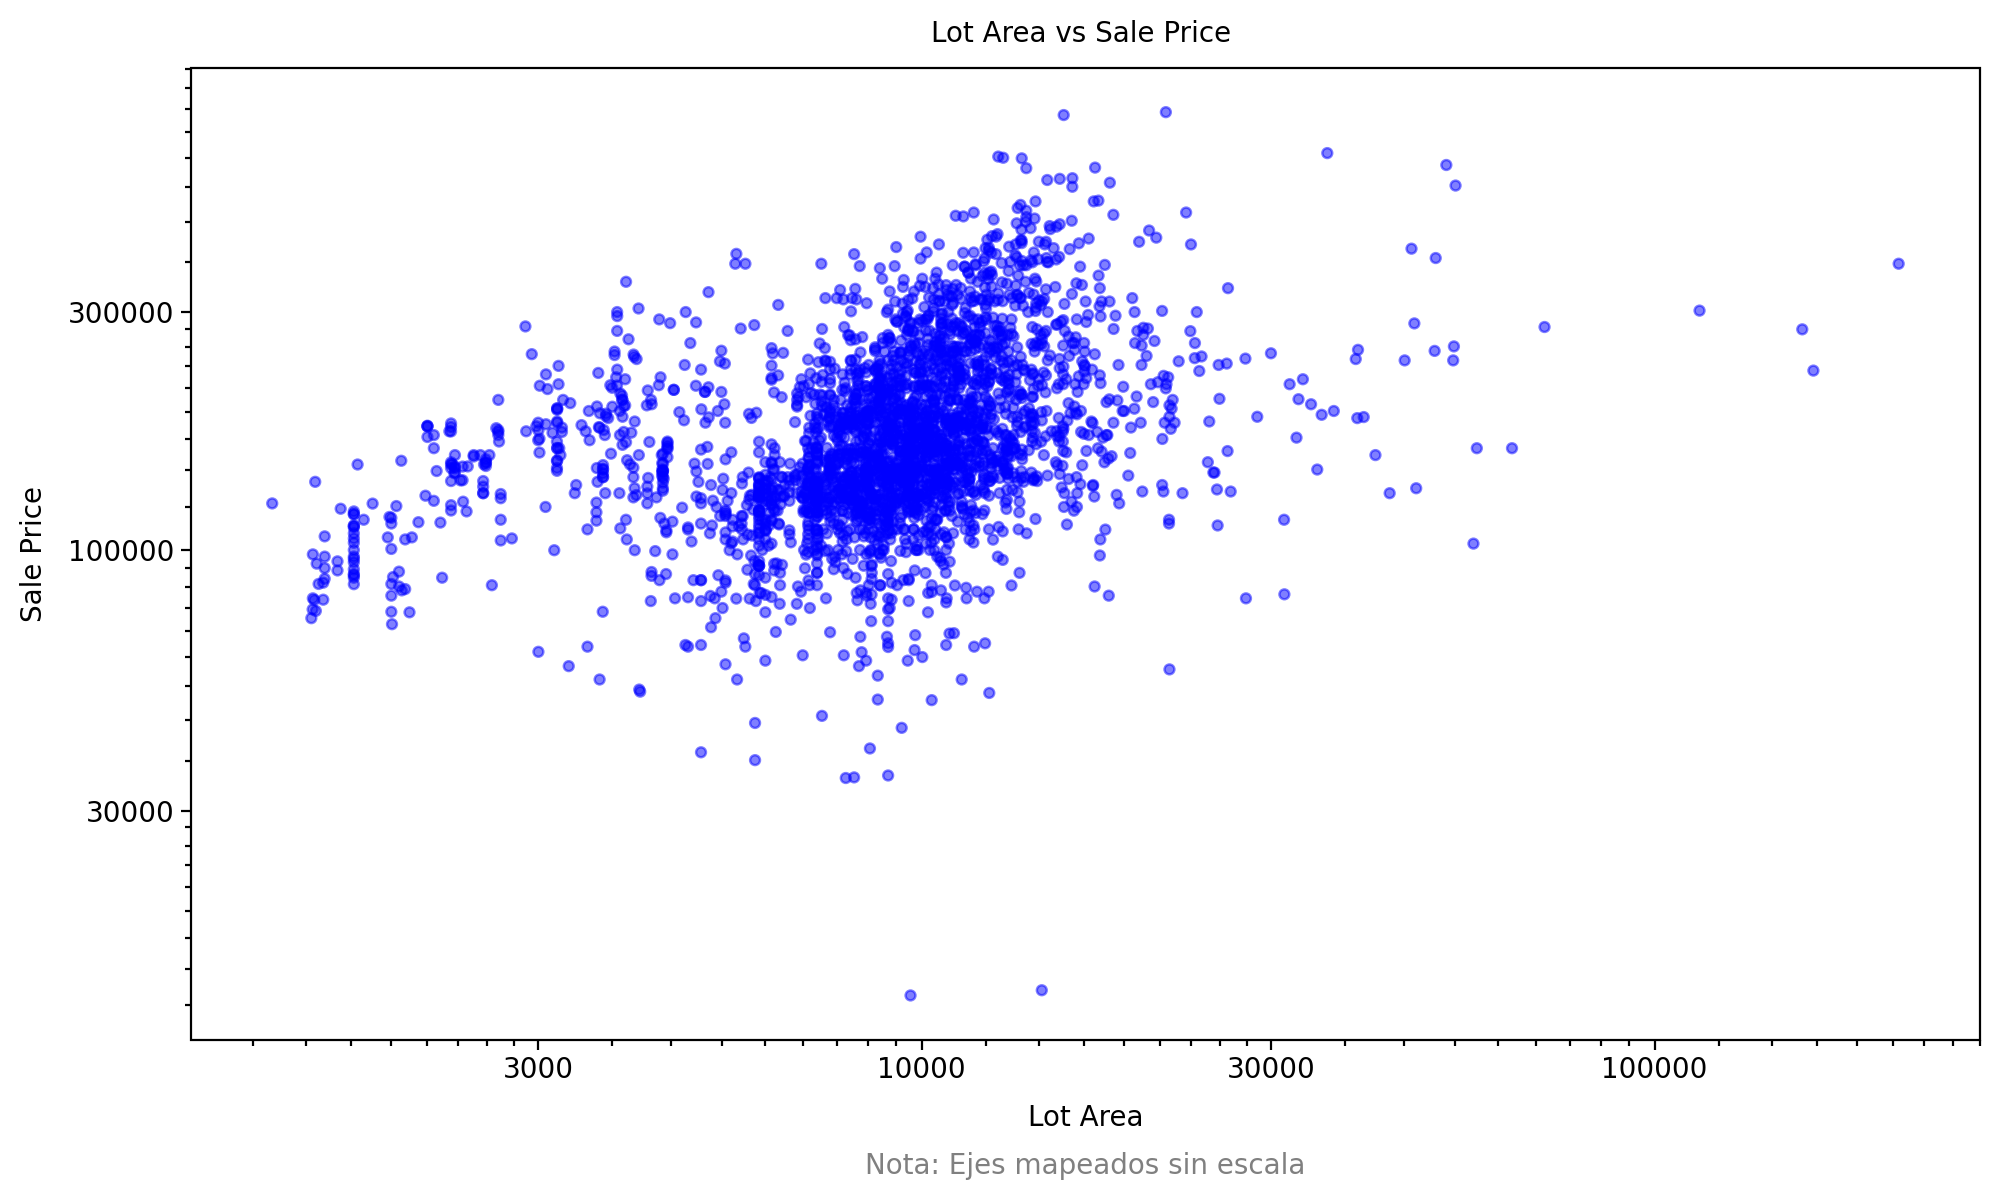

In [28]:
p = (
    ggplot(ames, aes(x='Lot_Area', y='Sale_Price'))
    + geom_point(color='blue', alpha=0.5)
    + scale_x_log10()
    + scale_y_log10()
    + labs(
        x='Lot Area',
        y='Sale Price',
        title='Lot Area vs Sale Price ',
        caption='Nota: Ejes mapeados sin escala'
    )
    + theme_matplotlib()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(ha='center'),
        plot_caption=element_text(ha='center', color='gray', size=10)
    )
)

p


# relacion entre variables 

C:\Users\cecir\AppData\Local\Temp\ipykernel_26244\2636539448.py:43: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


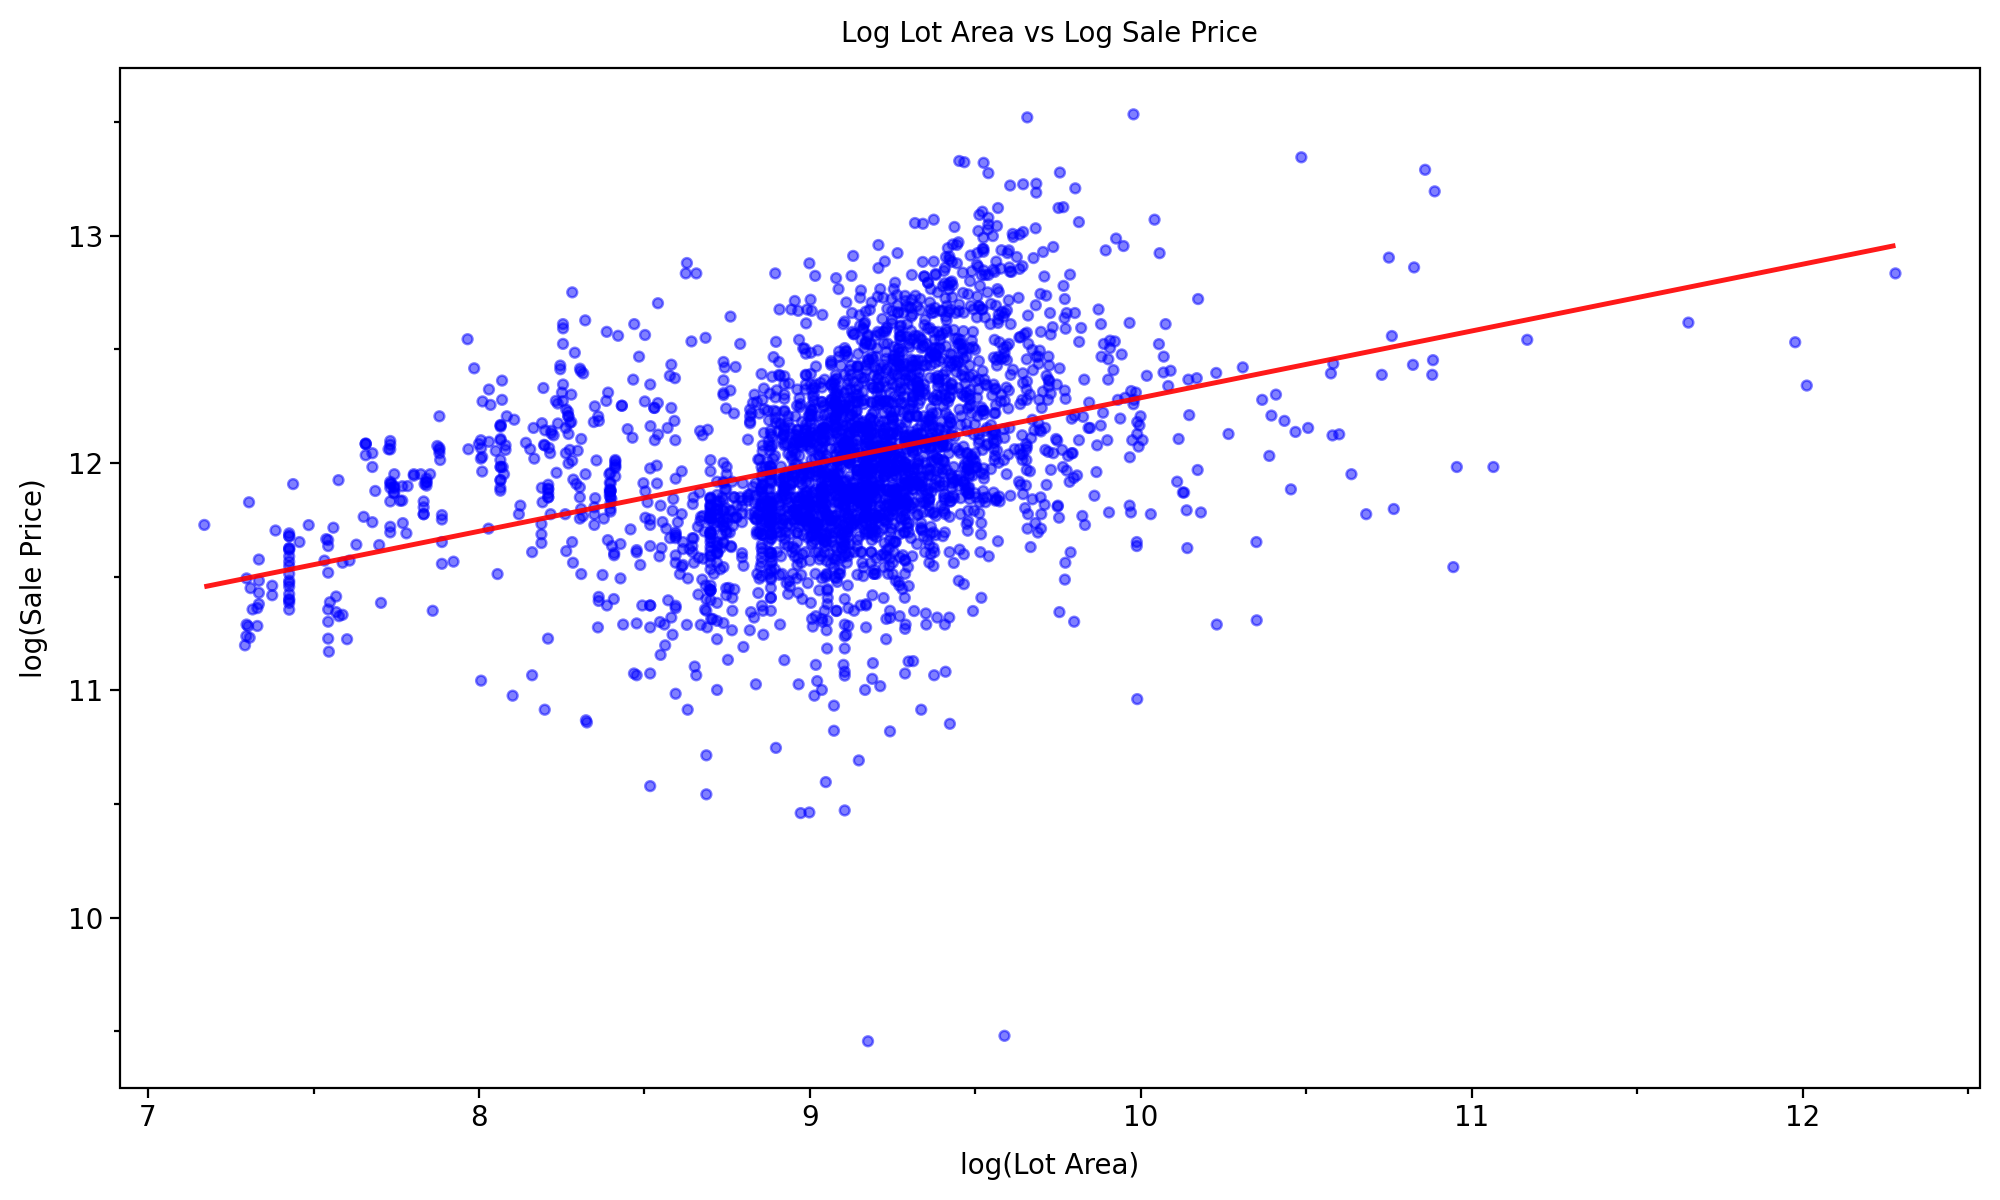

In [46]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_point, geom_line, labs,
    theme, element_text
)
from plotnine.themes import theme_matplotlib
from scipy.stats import linregress

# Ajuste en log-espacio
slope, intercept, _, _, _ = linregress(
    ames['log_Lot_Area'],
    ames['log_Sale_Price']
)

# Datos para la línea en log-espacio
x_log = np.linspace(ames['log_Lot_Area'].min(), ames['log_Lot_Area'].max(), 200)
line_df = pd.DataFrame({
    'log_Lot_Area': x_log,
    'log_Sale_Price_pred': intercept + slope * x_log
})

p = (
    ggplot(ames, aes(x='log_Lot_Area', y='log_Sale_Price'))
    + geom_point(color='blue', alpha=0.5)
    + geom_line(
        data=line_df,
        mapping=aes(x='log_Lot_Area', y='log_Sale_Price_pred'),
        color='red', size=1, alpha=0.9
    )
    + labs(
        x='log(Lot Area)',
        y='log(Sale Price)',
        title='Log Lot Area vs Log Sale Price'
    )
    + theme_matplotlib()
    + theme(
        figure_size=(10, 6),
        plot_title=element_text(ha='center')
    )
)

print(p)

## Variables transformadas en la regresion

In [48]:
qual_mapping = {
    'Very_Excellent': 10,
    'Excellent': 9,
    'Very_Good': 8,
    'Good': 7,
    'Above_Average': 6,
    'Average': 5,
    'Below_Average': 4,
    'Fair': 3,
    'Poor': 2,
    'Very_Poor': 1
}



In [52]:
qual_columns = ames.filter(regex='_Qual$').applymap(qual_mapping.get)


C:\Users\cecir\AppData\Local\Temp\ipykernel_26244\3760994018.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.


In [53]:
correlation_matrix = qual_columns.corr().round(2)


In [55]:
correlation_matrix.head()

,Overall_Qual,Exter_Qual,Bsmt_Qual,Kitchen_Qual,Garage_Qual
Overall_Qual,1.00,0.63,0.58,0.57,0.49
Exter_Qual,0.63,1.00,0.55,0.68,0.55
Bsmt_Qual,0.58,0.55,1.00,0.55,0.62
Kitchen_Qual,0.57,0.68,0.55,1.00,0.41
Garage_Qual,0.49,0.55,0.62,0.41,1.00


In [ ]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_tile, annotate, scale_fill_cmap, labs,
    theme, element_text, coord_equal
)

# 1) Pasar de matriz ancha a formato largo
corr_df = (
    correlation_matrix
    .reset_index()
    .melt(id_vars='index', var_name='variable', value_name='correlacion')
    .rename(columns={'index': 'feature'})
)

# 2) Etiquetas de texto para anotar cada celda
corr_df['label'] = corr_df['correlacion'].round(2).astype(str)



In [59]:
corr_df.head()

,feature,variable,correlacion,label
0,Overall_Qual,Overall_Qual,1.00,1.0
1,Exter_Qual,Overall_Qual,0.63,0.63
2,Bsmt_Qual,Overall_Qual,0.58,0.58
3,Kitchen_Qual,Overall_Qual,0.57,0.57
4,Garage_Qual,Overall_Qual,0.49,0.49


c:\Users\cecir\AppData\Local\Programs\Python\Python311\Lib\site-packages\plotnine\scales\scale.py:130: PlotnineWarning: scale_fill_cmap could not recognise parameter `cmap`
C:\Users\cecir\AppData\Local\Temp\ipykernel_26244\3311408275.py:25: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


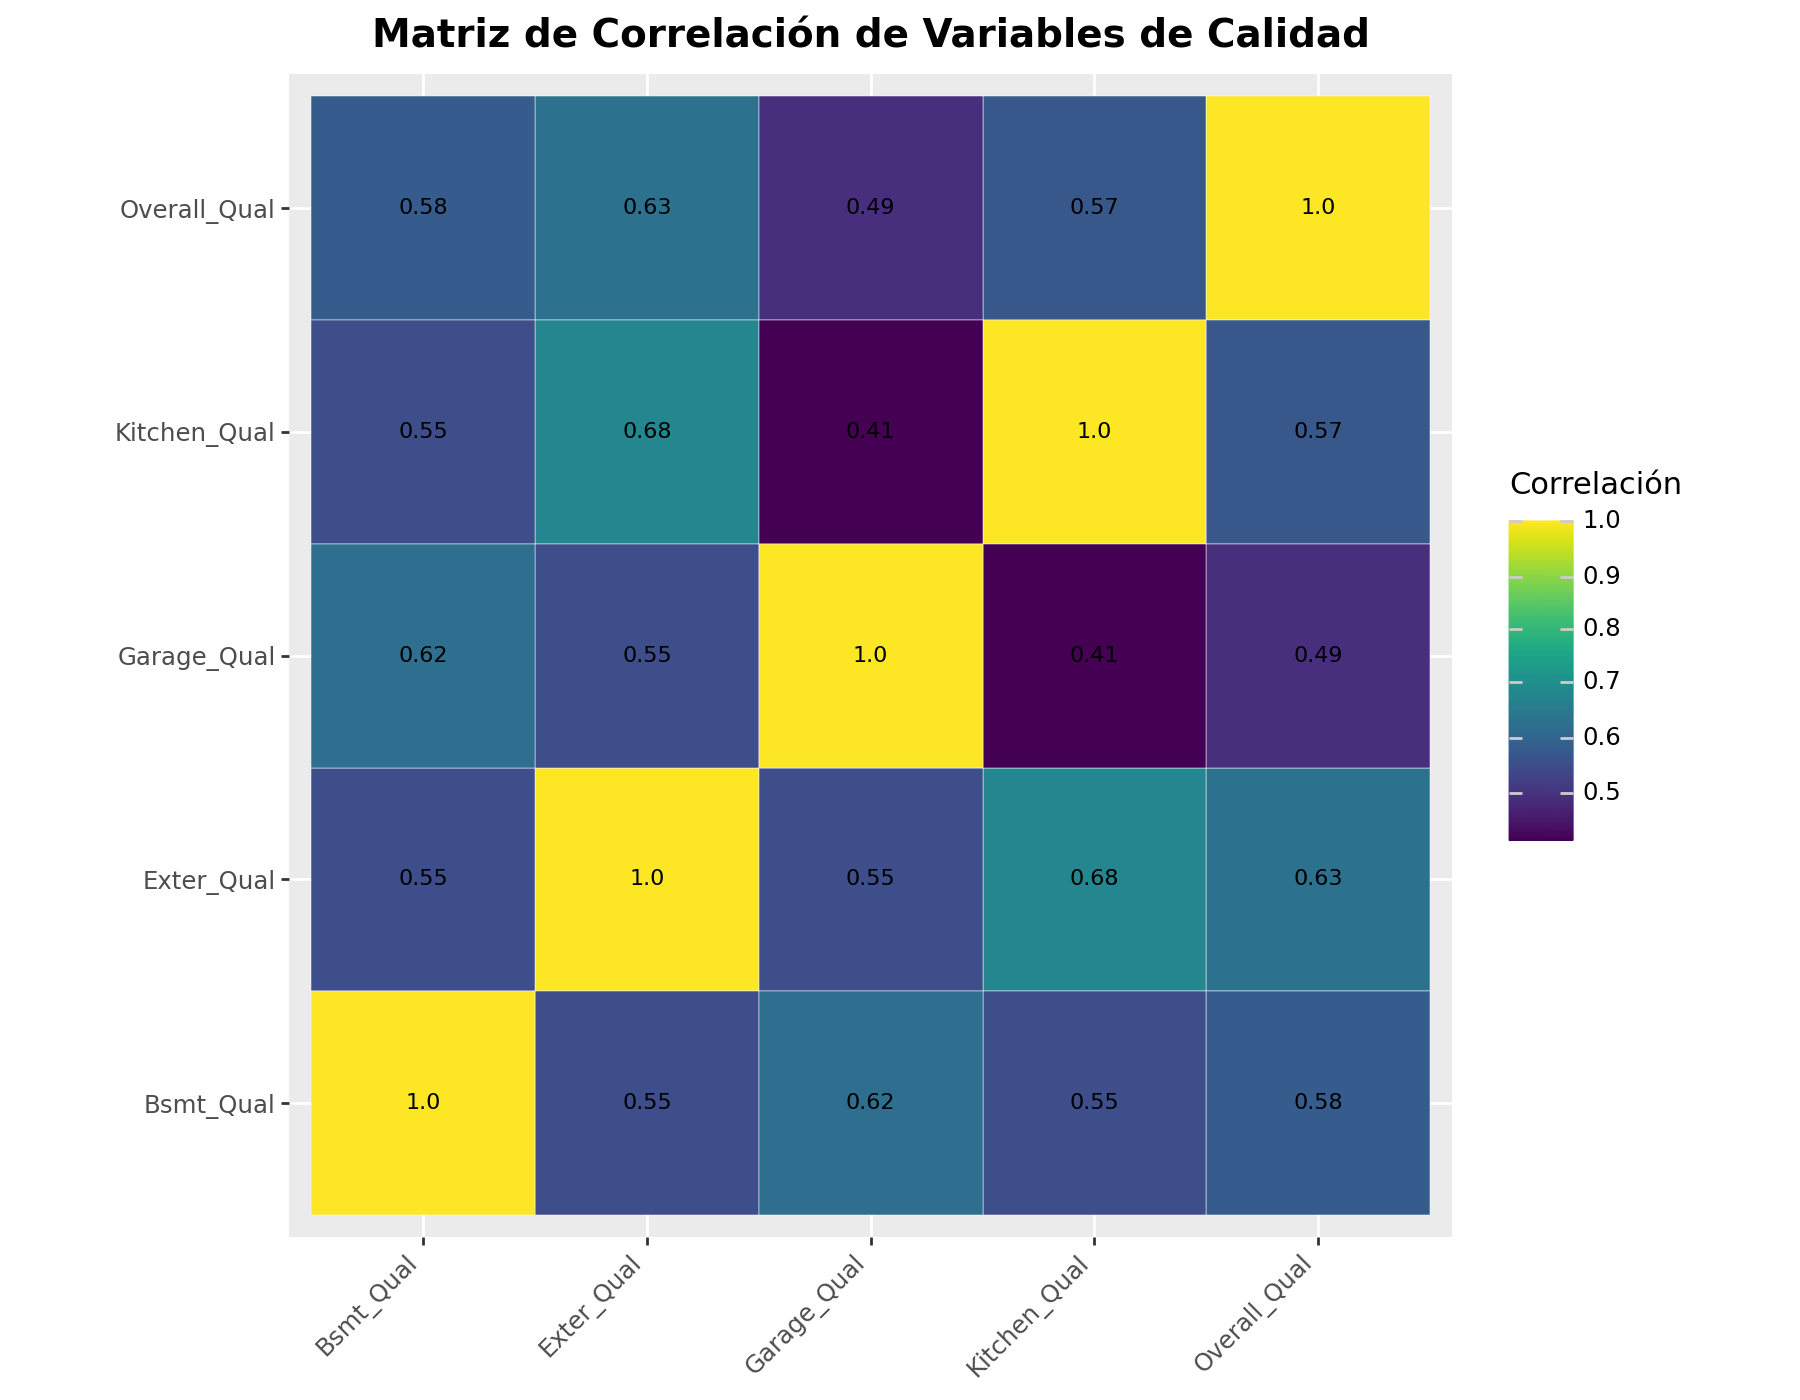

In [61]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_tile, geom_text, scale_fill_cmap, labs,
    theme, element_text, coord_equal
)

p = (
    ggplot(corr_df, aes(x='variable', y='feature', fill='correlacion'))
    + geom_tile(color='white')
    + geom_text(aes(label='label'), va='center', ha='center', size=8, color='black')
    + scale_fill_cmap(cmap='coolwarm', name='Correlación')
    + labs(
        title='Matriz de Correlación de Variables de Calidad',
        x='', y=''
    )
    + theme(
        figure_size=(9, 7),
        axis_text_x=element_text(rotation=45, ha='right'),
        plot_title=element_text(ha='center', size=14, weight='bold')
    )
    + coord_equal()
)

print(p)

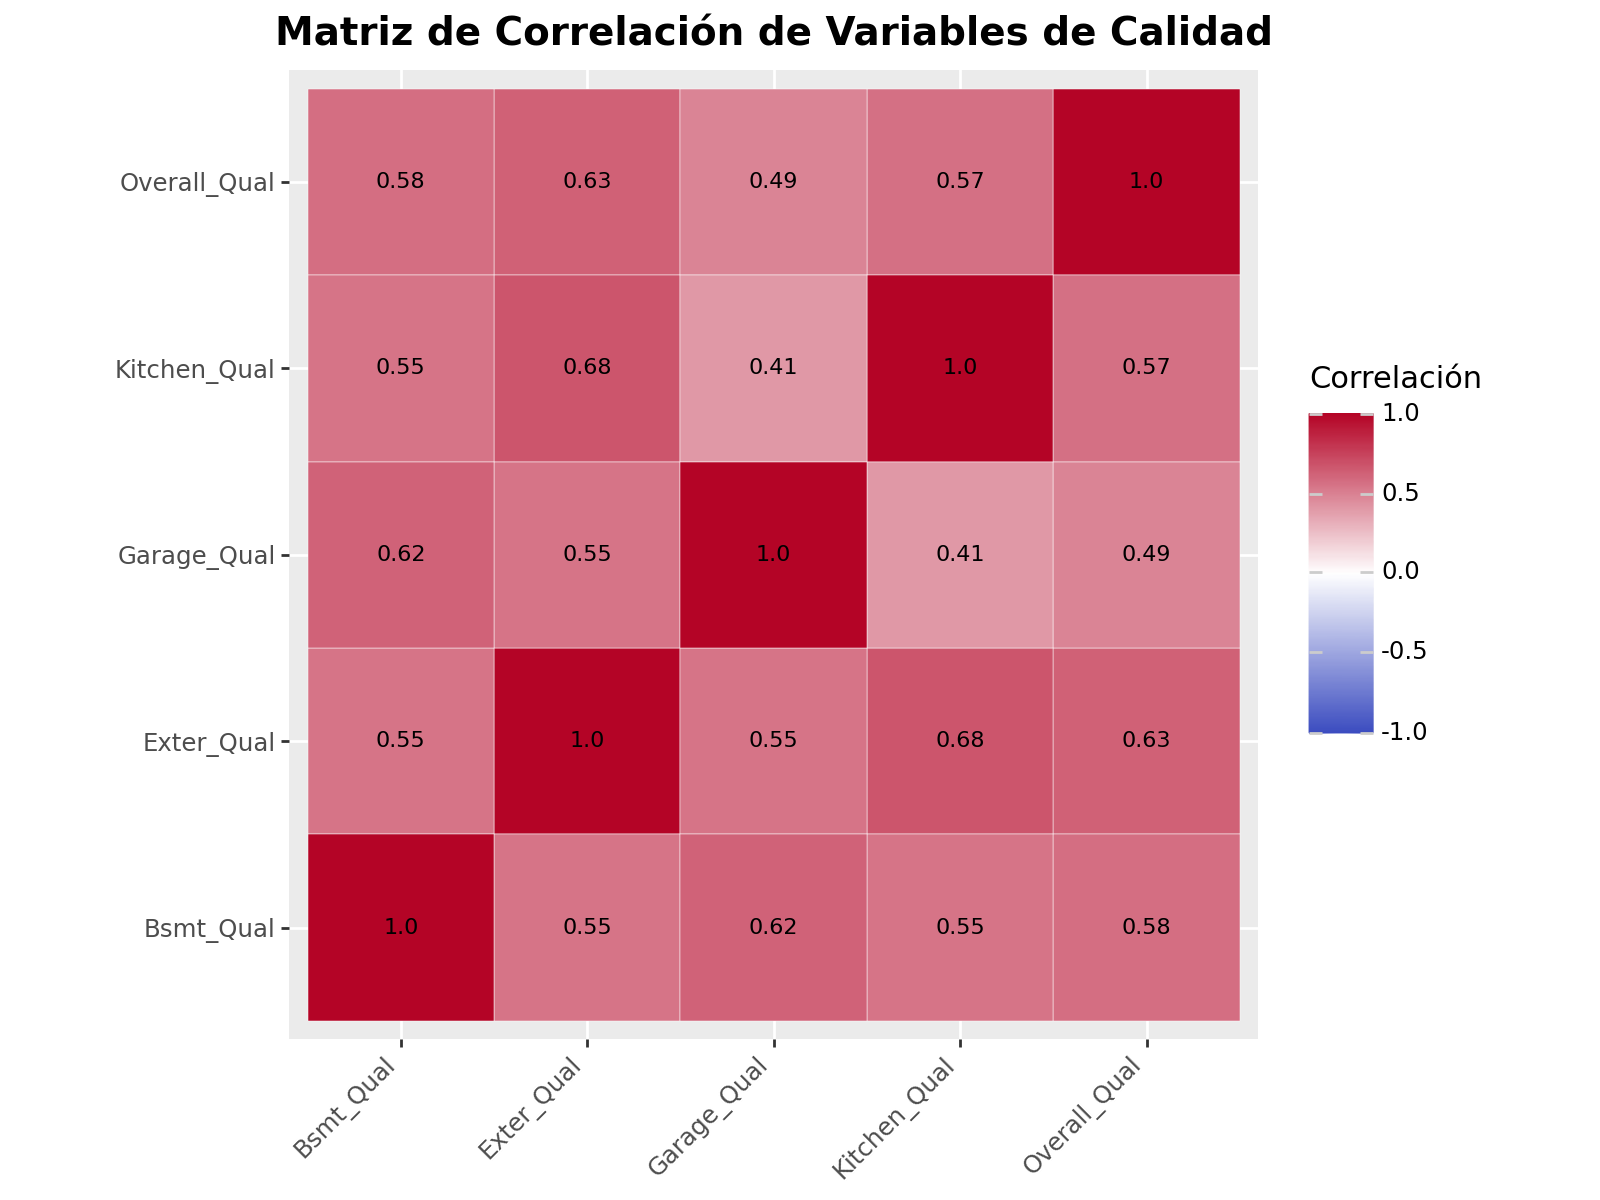

In [63]:


import pandas as pd
from plotnine import (
    ggplot, aes, geom_tile, geom_text, labs,
    theme, element_text, coord_equal, scale_fill_gradient2
)

p = (
    ggplot(corr_df, aes(x='variable', y='feature', fill='correlacion'))
    + geom_tile(color='white')

    # Anotaciones en cada celda
    + geom_text(aes(label='label'), color='black', size=8)

    # Paleta divergente centrada en 0 (como coolwarm)
    + scale_fill_gradient2(
        low='#3B4CC0', mid='white', high='#B40426',
        midpoint=0, limits=(-1, 1),
        name='Correlación'
    )

    + labs(
        title='Matriz de Correlación de Variables de Calidad',
        x='', y=''
    )

    + theme(
        figure_size=(8, 6),
        axis_text_x=element_text(rotation=45, ha='right'),
        plot_title=element_text(ha='center', size=14, weight='bold')
    )

    # Mantener celdas cuadradas
    + coord_equal()
)

p

In [45]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

Generar una Máscara para el Triángulo Superior: Se crea una máscara utilizando np.triu para ocultar la mitad superior de la matriz de correlación.

np.triu() stands for "triangle upper" and is a NumPy function that extracts the upper triangle of an array and sets all elements below the diagonal to zero.
By default, np.triu() extracts the upper triangle including the diagonal (k=0).

In [65]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_tile, geom_text, labs,
    theme, element_text, coord_equal, scale_fill_gradient2
)

# ---------------------------------------------------------------------
# 0) Asegurar que 'correlation_matrix' es cuadrada y con mismo orden
# Alinear índice y columnas si hiciera falta, y fijar un orden explícito
order = list(correlation_matrix.columns)
correlation_matrix = correlation_matrix.reindex(index=order, columns=order)

# ---------------------------------------------------------------------
# 1) Pasar matriz ancha a formato largo
corr_df = (
    correlation_matrix
    .reset_index()
    .melt(id_vars='index', var_name='variable', value_name='correlacion')
    .rename(columns={'index': 'feature'})
)

#  Asegurar que el orden se preserva visualmente
corr_df['feature'] = pd.Categorical(corr_df['feature'], categories=order, ordered=True)
corr_df['variable'] = pd.Categorical(corr_df['variable'], categories=order, ordered=True)

# ---------------------------------------------------------------------
# 2) Crear índices posicionales para filas/columnas
pos = {name: i for i, name in enumerate(order)}
corr_df['i'] = corr_df['feature'].map(pos)
corr_df['j'] = corr_df['variable'].map(pos)

# Validación rápida (evita KeyError si algo salió mal)
assert corr_df['i'].notna().all() and corr_df['j'].notna().all(), \
    f"Algunas categorías no mapearon a posiciones. Revisa orden: {order}"



C:\Users\cecir\AppData\Local\Temp\ipykernel_26244\4074408402.py:29: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


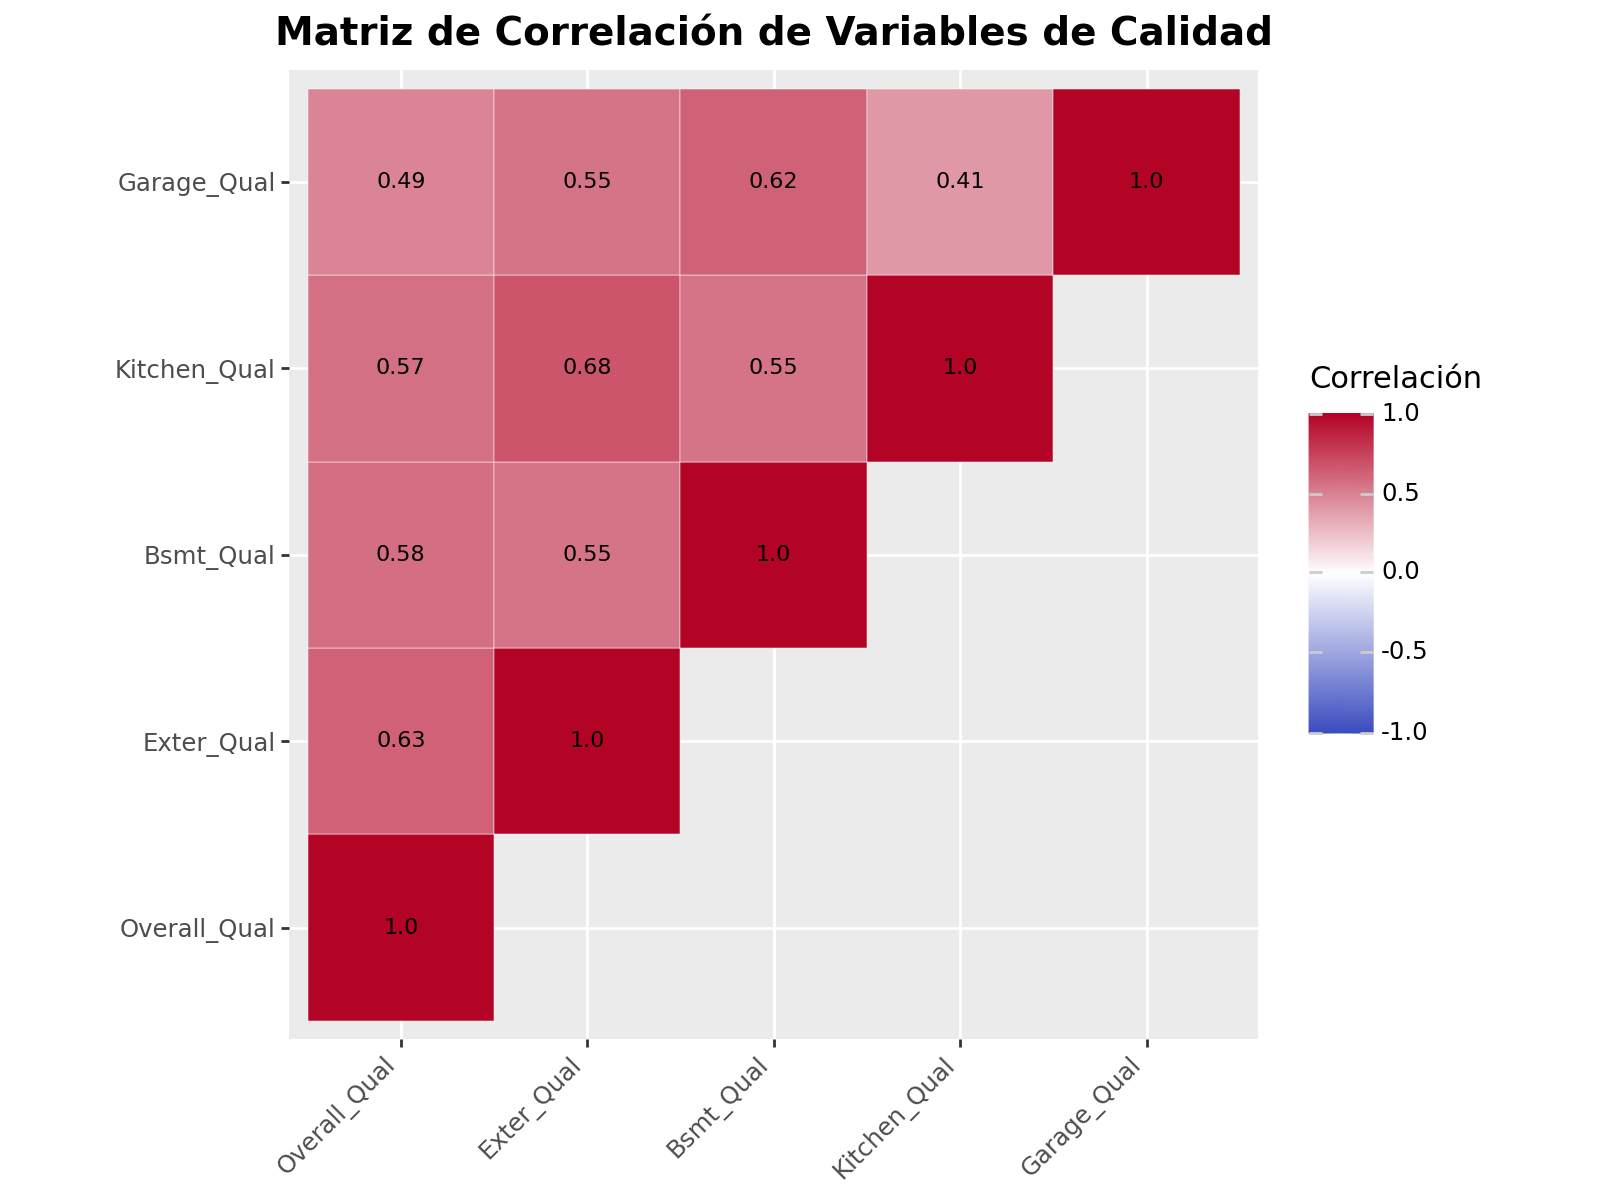

In [66]:

#    Para triángulo superior usa: corr_df = corr_df[corr_df['i'] <= corr_df['j']].copy()
corr_df = corr_df[corr_df['i'] >= corr_df['j']].copy()

# Etiquetas para anotar
corr_df['label'] = corr_df['correlacion'].round(2).astype(str)

# ---------------------------------------------------------------------
# 4) Heatmap con anotaciones
p = (
    ggplot(corr_df, aes(x='variable', y='feature', fill='correlacion'))
    + geom_tile(color='white')
    + geom_text(aes(label='label'), color='black', size=8)
    + scale_fill_gradient2(
        low='#3B4CC0', mid='white', high='#B40426',
        midpoint=0, limits=(-1, 1), name='Correlación'
    )
    + labs(
        title='Matriz de Correlación de Variables de Calidad',
        x='', y=''
    )
    + theme(
        figure_size=(8, 6),
        axis_text_x=element_text(rotation=45, ha='right'),
        plot_title=element_text(ha='center', size=14, weight='bold')
    )
    + coord_equal()
)

print(p)

C:\Users\cecir\AppData\Local\Temp\ipykernel_26244\4089446481.py:76: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


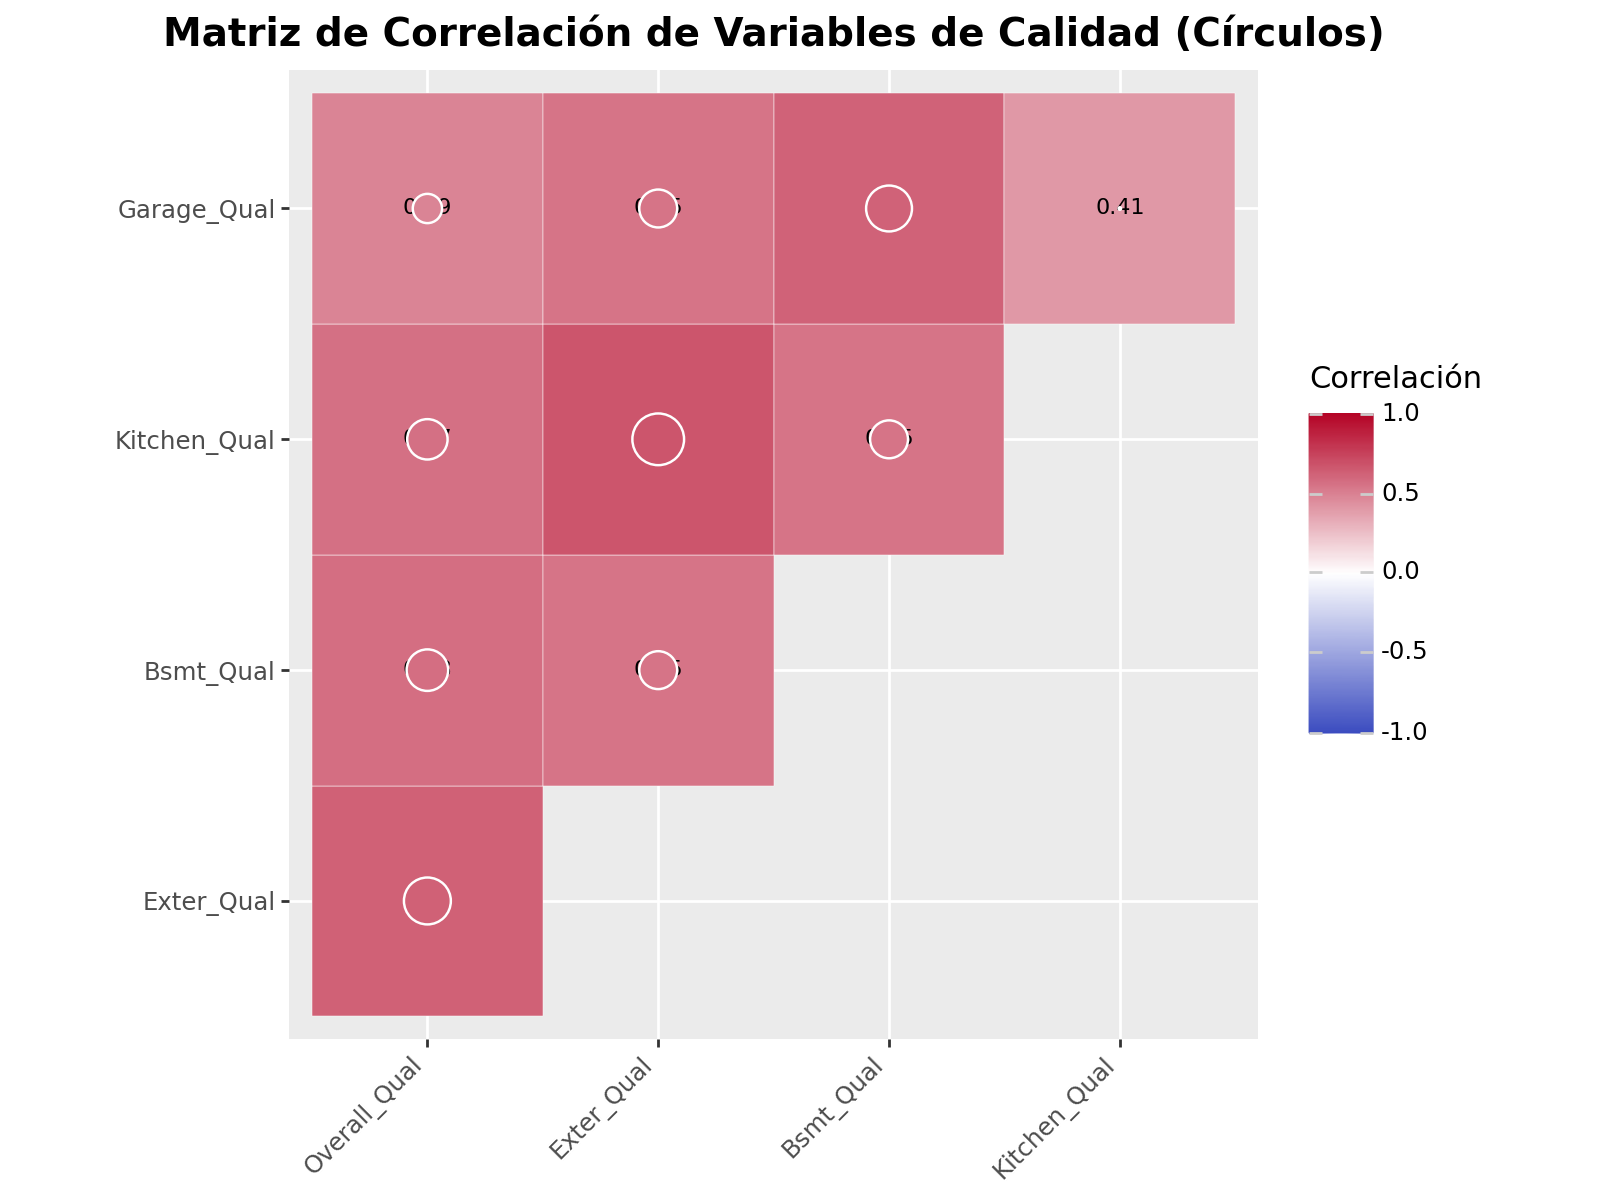

In [ ]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_tile, geom_text, geom_point,
    labs, theme, element_text, coord_equal,
    scale_fill_gradient2, scale_size
)

# ---------------------------------------------------------------------

order = list(correlation_matrix.columns)
correlation_matrix = correlation_matrix.reindex(index=order, columns=order)

try:
    mask
except NameError:
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # superior

# --- 1) Matriz -> formato largo
corr_df = (
    correlation_matrix
    .reset_index()
    .melt(id_vars='index', var_name='variable', value_name='correlacion')
    .rename(columns={'index': 'feature'})
)
corr_df['feature'] = pd.Categorical(corr_df['feature'], categories=order, ordered=True)
corr_df['variable'] = pd.Categorical(corr_df['variable'], categories=order, ordered=True)

# --- 2) Aplanar la mask y filtrar visibles
mask_df = (
    pd.DataFrame(mask, index=order, columns=order)
      .reset_index()
      .melt(id_vars='index', var_name='variable', value_name='masked')
      .rename(columns={'index': 'feature'})
)
mask_df['feature'] = pd.Categorical(mask_df['feature'], categories=order, ordered=True)
mask_df['variable'] = pd.Categorical(mask_df['variable'], categories=order, ordered=True)

corr_vis = corr_df.merge(mask_df, on=['feature', 'variable'], how='left')
corr_vis['masked'] = corr_vis['masked'].fillna(False)
corr_vis = corr_vis[~corr_vis['masked']].copy()

# --- 3) Etiquetas y tamaño de círculo
corr_vis['label'] = corr_vis['correlacion'].round(2).astype(str)
corr_vis['abs_corr'] = corr_vis['correlacion'].abs()

# --- 4) Plot
p = (
    ggplot(corr_vis, aes(x='variable', y='feature', fill='correlacion'))
    + geom_tile(color='white')
    + geom_text(aes(label='label'), color='black', size=8)
    # Desactivar leyenda del tamaño desde la capa (evita el error)
    + geom_point(
        aes(size='abs_corr'),
        shape='o', color='white',  # círculo hueco
        show_legend=False
    )
    + scale_size(range=(0, 10))  # controla el tamaño de los círculos
    + scale_fill_gradient2(
        low='#3B4CC0', mid='white', high='#B40426',
        midpoint=0, limits=(-1, 1), name='Correlación'
    )
    + labs(
        title='Matriz de Correlación de Variables de Calidad (Círculos)',
        x='', y=''
    )
    + theme(
        figure_size=(8, 6),
        axis_text_x=element_text(rotation=45, ha='right'),
        plot_title=element_text(ha='center', size=14, weight='bold')
    )
    + coord_equal()
)

print(p)   # o p.show()

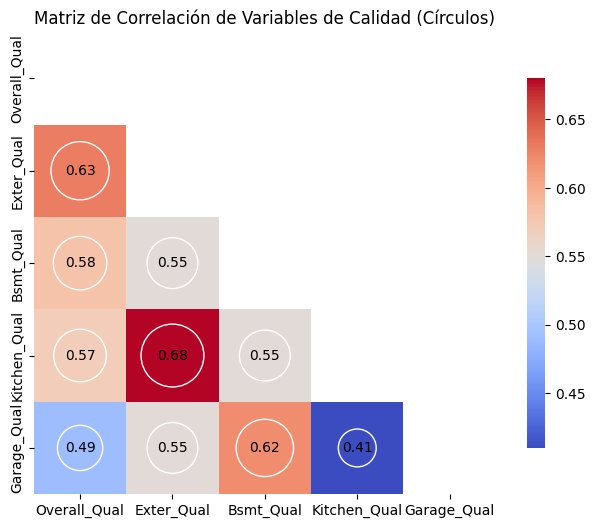

In [70]:
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        if not mask[i, j]:
            plt.text(j + 0.5, i + 0.5, correlation_matrix.iloc[i, j],
                     ha='center', va='center', fontsize=10)
            size = np.abs(correlation_matrix.iloc[i, j])
            circle = plt.Circle((j + 0.5, i + 0.5), size / 2, color='white', fill=False)
            plt.gca().add_artist(circle)

plt.title('Matriz de Correlación de Variables de Calidad (Círculos)')
plt.show()